# Prequisite (cukup jalankan sekali)


In [ ]:
import nltk

# nltk.download('stopwords')
# nltk.download('words')
# nltk.download('wordnet')
# nltk.download('averaged_perceptron_tagger')
# nltk.download('averaged_perceptron_tagger_eng')

# Import

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import seaborn as sns

import emoji
from wordcloud import WordCloud
import nltk

from collections import Counter
import math

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.feature_selection import chi2, SelectPercentile
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

from text_preprocessing import preprocess_pipeline
from sklearn.pipeline import Pipeline
import pickle

import re
from nltk.corpus import stopwords
from nltk.corpus import words as nltk_words
from nltk.stem import WordNetLemmatizer
from nltk.corpus import wordnet


# Data Preview

In [2]:
import pandas as pd
df = pd.read_parquet('train.parquet')
df.head()

,text,label
0,hey I am looking for Xray baggage datasets can...,not_spam
1,"""Get rich quick! Make millions in just days wi...",spam
2,URGENT MESSAGE: YOU WON'T BELIEVE WHAT WE HAVE...,spam
3,[Google AI Blog: Contributing Data to Deepfake...,not_spam
4,Trying to see if anyone already has timestamps...,not_spam


In [3]:
df.shape

(8175, 2)

In [4]:
df.isnull().sum()

text     0
label    0
dtype: int64

In [5]:
print("Rata-rata panjang kata:", round(df['text'].apply(len).mean()))
print("Panjang maksimum kata:", df['text'].apply(len).max())
print("Panjang minimum kata:", df['text'].apply(len).min())

all_text = " ".join(df['text'].astype(str))
tokens = all_text.split()
word_counts = Counter(tokens)
print(f"Total kata: {len(word_counts)}")


Rata-rata panjang kata: 369
Panjang maksimum kata: 41544
Panjang minimum kata: 2
Total kata: 47144


In [6]:
df['label'].value_counts()

label
spam        4125
not_spam    4050
Name: count, dtype: int64

# EDA

### Distribusi noise

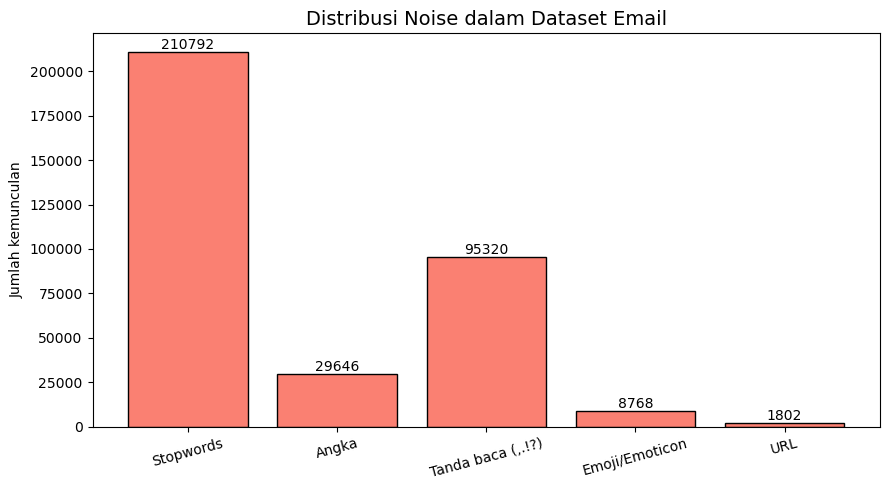

In [7]:
# Extract all words from dataset
all_words = ' '.join(df['text'].tolist())
stopword_en = set(stopwords.words('english'))

# Dictionary of noise count
noise = {
    'Stopwords': sum(all_words.lower().split().count(w) for w in stopword_en),
    'Angka': len(re.findall(r'\d', all_words)),
    'Tanda baca (,.!?)': len(re.findall(r'[,\.!?;:\"\']', all_words)),
    'Emoji/Emoticon': len(re.findall(r'[:;=]-?[\)\(\|DPp]|[\U0001F300-\U0001FFFF]', all_words)),
    'URL': len(re.findall(r'http\S+|www\S+', all_words)),
}

# Plot styling
plt.figure(figsize=(9, 5))
bars = plt.bar(noise.keys(), noise.values(), color='salmon', edgecolor='black')
plt.bar_label(bars)
plt.title('Distribusi Noise dalam Dataset Email', fontsize=14)
plt.ylabel('Jumlah kemunculan')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


- Mayoritas noise yang ada di dalam text adalah stopword. 
- Perlu di handling mana yang harus di hapus dan harus di masking agar tidak menginterferensi proses vectorization.

### Macam Emoji

In [8]:
print(re.findall(r'[:;=]-?[\)\(\|DPp]|[\U0001F300-\U0001FFFF]', all_words))

['👋', '👋', '👋', '😴', '😒', '🌶', '🌶', '🌶', '💪', '🏃', '🥦', '💪', '💪', '💪', '🙌', '🙌', '🙌', '🤩', '🤩', '🤩', '👋', '💥', '🤳', '🤳', '💻', '🔥', '🚫', '🔥', '🔥', '🤑', '💰', '💰', ':)', '👀', '📣', '📈', '🚀', '🤑', '👉', '💕', '💬', '🔧', '🛠', '👍', '📝', '👥', '🤩', '🌸', '🌸', '🌸', '🤩', '🤩', '🤩', '😝', '😝', '😝', '🤯', '🤯', '🤯', ';D', '😩', ':)', ':-|', ':-|', ':-|', '🎉', '🎉', '🎉', ';)', '🚨', '🚨', '🦐', '🦐', '🍔', '🍔', '🍟', '🍟', '💥', '💥', '🎁', '🤯', '🔥', '💥', '👨', '🎤', '👩', '🎤', '🔞', '🦄', '🤑', '🤑', '🤑', '🏃', '🏃', '🏃', '🥑', '🎉', '🥳', '💥', '🤑', '💪', '👟', '🌴', '🌞', '👀', '💬', '🤑', '💰', '🔥', '🔥', '🔥', '🔥', '🔥', '🔥', '🔥', '🔥', '👉', '🏼', '🤯', '🤯', '🚫', '👉', '🤑', '🎉', '👍', '🙌', '🚨', '🚨', '🚨', '🚨', '🚨', '🚨', '🔥', '🔥', '🔥', '🔥', '🔥', '🔥', '🎉', '🎉', '🎉', '🎉', '🎉', '🎉', '🤑', '🤑', '🤑', '🤑', '🤑', '🚨', '🚨', '🏋', '🏋', '💪', '💪', '📚', '🤑', '💰', '🤑', '💰', '🤑', '📣', '📣', '📣', '😎', '🚨', '🚨', '🎉', '🎉', '🎉', '🤡', '🐱', '😜', '😂', '👌', '🔥', '🔥', '🔥', '🤑', '🤑', '🤑', '🎉', '🎉', '🎉', '🥧', '🥧', '🥧', '💰', '💰', '💰', '=p', '=p', '=p', '👉', '👉', '👉', '🤑', '

### Preview bentuk asli noise

D:\Users\bsi80273\AppData\Local\Temp\ipykernel_12000\1528004515.py:66: UserWarning: Glyph 128313 (\N{SMALL BLUE DIAMOND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
c:\ProgramData\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128313 (\N{SMALL BLUE DIAMOND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


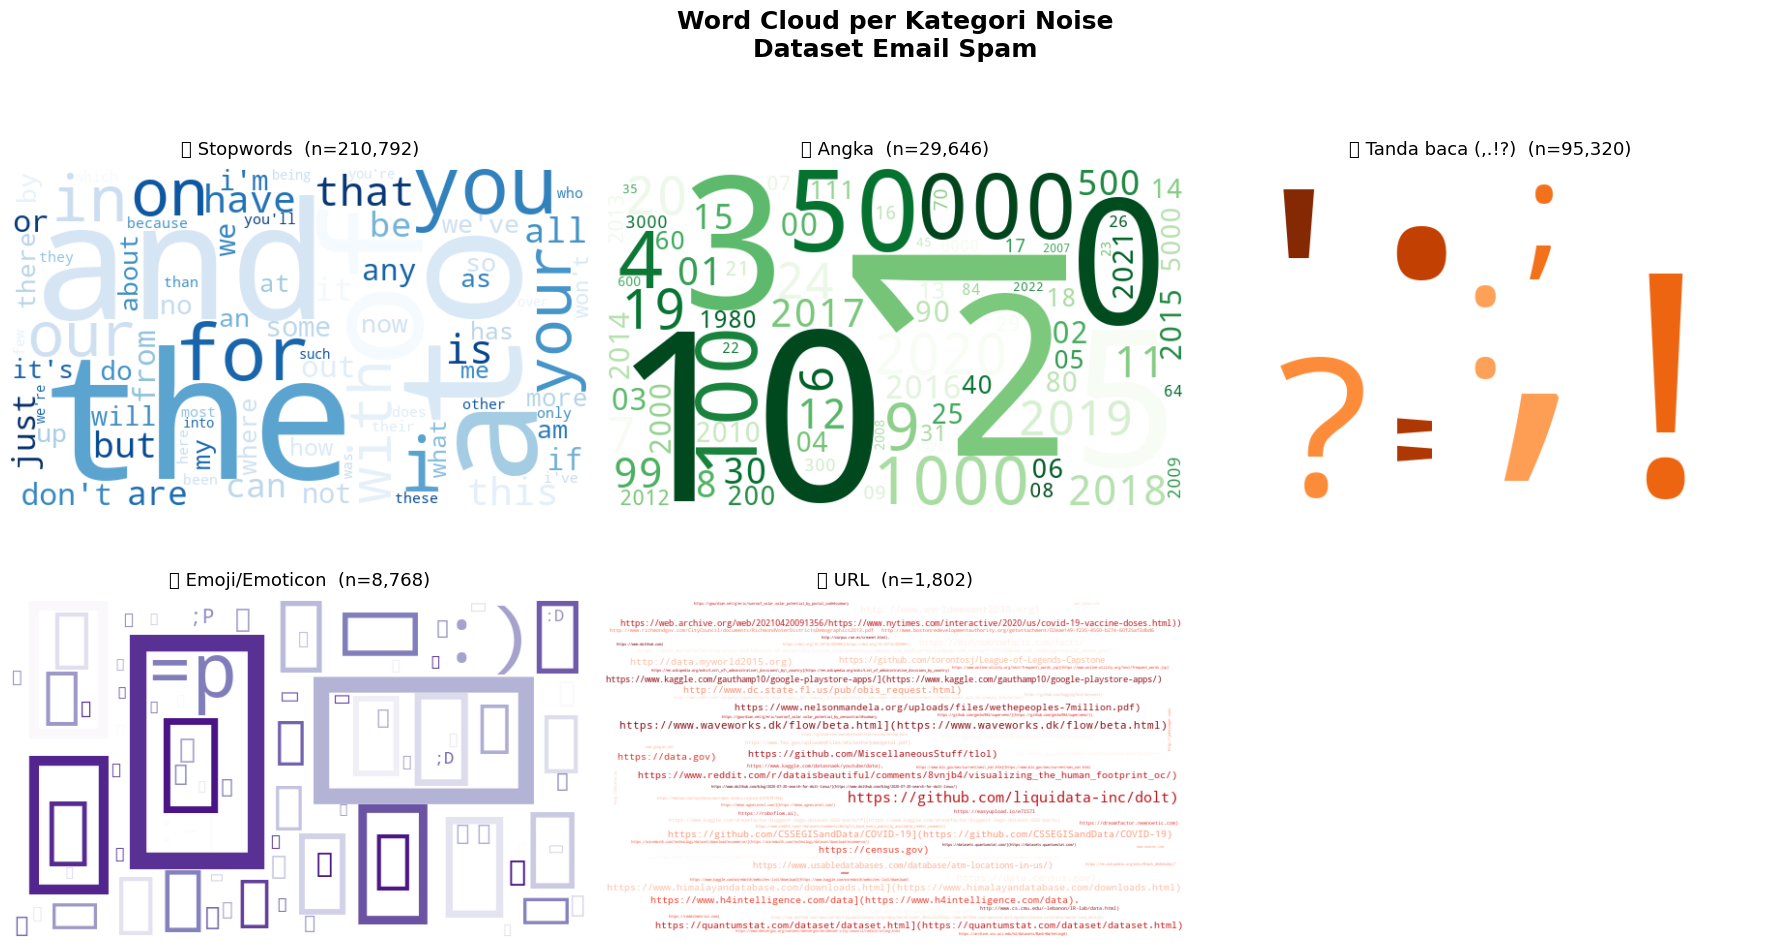

In [9]:
# Tokenisasi per kata
tokens = all_words.lower().split()

# Dictionary of noise frequency count
noise_freq = {
    'Stopwords': Counter(w for w in tokens if w in stopword_en),
    'Angka': Counter(re.findall(r'\b\d+\b', all_words)),
    'Tanda baca (,.!?)': Counter(re.findall(r'[,\.!?;:\"\']', all_words)),
    'Emoji/Emoticon': Counter(re.findall(r'[:;=]-?[\)\(\|DPp]|[\U0001F300-\U0001FFFF]', all_words)),
    'URL': Counter(re.findall(r'http\S+|www\S+', all_words)),
}

# Dictionary of colormap for each noise category
cmap_map = {
    'Stopwords': 'Blues',
    'Angka': 'Greens',
    'Tanda baca (,.!?)': 'Oranges',
    'Emoji/Emoticon': 'Purples',
    'URL': 'Reds',
}

# Function to generate Word Cloud
def make_wc(freq_dict: Counter[str, str], colormap: str, max_words=80):
    """
    Membuat Word Cloud dari frequency dictionary.
    """
    wc = WordCloud(
        width=600, height=350,
        background_color='white',
        colormap=colormap,
        max_words=max_words,
        collocations=False,
    )
    if freq_dict:
        wc.generate_from_frequencies(freq_dict)
    return wc

# Layouting
n = len(noise)
ncols = 3
nrows = -(-n // ncols)  


# Plotting Word Cloud
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 6, nrows * 5))
fig.suptitle('Word Cloud per Kategori Noise\nDataset Email Spam',
             fontsize=18, fontweight='bold', y=1.01)

for ax, (label, freq) in zip(axes.flatten(), noise_freq.items()):
    cmap = cmap_map.get(label, 'cool')
    if freq:
        wc = make_wc(freq, cmap)
        ax.imshow(wc, interpolation='bilinear')
        ax.set_title(f'🔹 {label}  (n={noise[label]:,})', fontsize=13, pad=10)
    else:
        ax.text(0.5, 0.5, 'Tidak ditemukan',
                ha='center', va='center', fontsize=13, color='gray',
                transform=ax.transAxes)
        ax.set_title(f'🔹 {label}', fontsize=13, pad=10)
    ax.axis('off')

# Sembunyikan ax kosong
for ax in axes.flatten()[n:]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

- Pada noise url, ada url yang mungkin tidak boleh di hapus karena biasanya url yang domain .com, .id itu adalah bukan email spam.

### Cek kata terpanjang, terpendek, dan null

In [10]:
df['text_length'] = df['text'].apply(len) # Tambah kolom panjang kata

<Axes: >

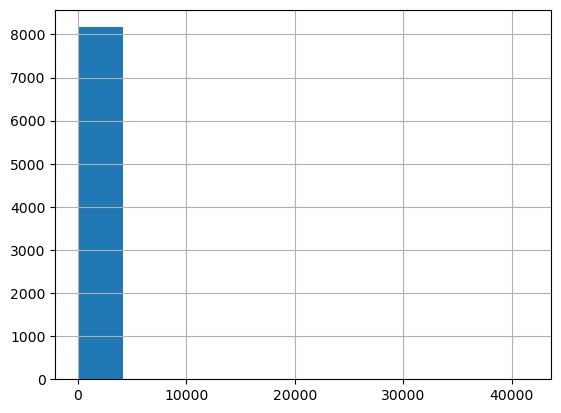

In [11]:
df['text_length'].hist()

In [12]:
df[df['text_length'] == 41544] # Cek kata terpanjang

,text,label,text_length
6262,I've made a zip code-level data retriever in R...,not_spam,41544


In [13]:
df[df['text_length'] == 0] # Cek kata null

,text,label,text_length


In [14]:
df[df['text_length'] < 10] # Cek kata terpendek (kurang dari 10 character)

,text,label,text_length
1569,^^,not_spam,2
2949,See title,not_spam,9
3142,TIA :),not_spam,6
3687,Title.,not_spam,6
3987,Thanks!,not_spam,7
5765,question,not_spam,8
7788,Thanks,not_spam,6


In [15]:
df[['text_length']].describe()

,text_length
count,8175.000000
mean,369.111315
std,565.820388
min,2.000000
25%,175.000000
50%,284.000000
75%,507.000000
max,41544.000000


- Mayoritas panjang text ada di bawah 500 kata.
- Ada text yang panjangnya lebih dari 40K karakter.
- Ada text yang panjangnya hanya dari 2 karakter.

### Spam vs Non Spam

In [16]:
def extract_noise(text):
    stopword_en = set(stopwords.words('english'))
    words = text.lower().split()

    return pd.Series({
        'stopwords': sum(w in stopword_en for w in words),

        'angka': len(re.findall(r'\d', text)),

        'tanda_baca': len(
            re.findall(r'[,\.!?;:\"\']', text)
        ),

        'emoji': len(
            re.findall(
                r'[:;=]-?[\)\(\|DPp]|[\U0001F300-\U0001FFFF]',
                text
            )
        ),

        'url': len(
            re.findall(r'http\S+|www\S+', text)
        )
    })

# =========================
# tambah kolom
# =========================
df_corr = df.copy()
df_corr[
    ['stopwords',
     'angka',
     'tanda_baca',
     'emoji',
     'url']
] = df_corr['text'].apply(extract_noise)

df_corr['label'] = df_corr['label'].map({'spam': 1, "not_spam": 0})
df_corr.head()

,text,label,text_length,stopwords,angka,tanda_baca,emoji,url
0,hey I am looking for Xray baggage datasets can...,0,76,9,0,0,0,0
1,"""Get rich quick! Make millions in just days wi...",1,129,9,0,6,0,0
2,URGENT MESSAGE: YOU WON'T BELIEVE WHAT WE HAVE...,1,495,46,0,24,0,0
3,[Google AI Blog: Contributing Data to Deepfake...,0,1057,35,16,41,0,7
4,Trying to see if anyone already has timestamps...,0,223,19,0,6,0,0


<Axes: >

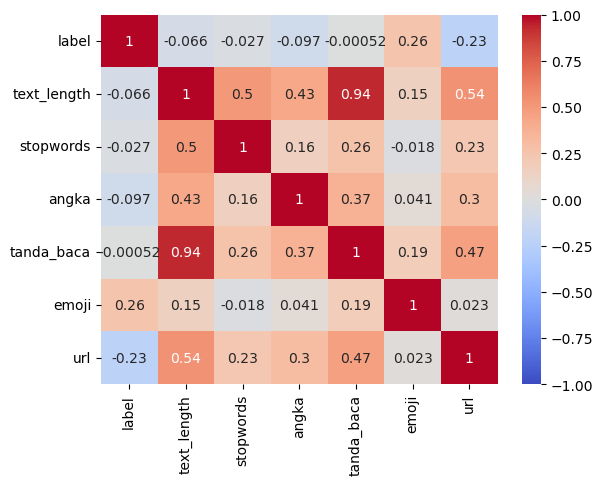

In [17]:
sns.heatmap(df_corr.select_dtypes(include='number').corr(), annot=True,
            vmin=-1, vmax=1, cmap='coolwarm')

- Emoji dan Url memiliki korelasi positif terhadap label. Artinya semakin banyak emoji dan url dapat diduga email tersebut adalah spam

# Masking

Masking bertujuan untuk tidak membuang kata yang dianggap dapat berkontribusi dalam menciptakan pola spam dan non spam email. contohnya:
- url dengan domain .com, .id
- Angka yang menunjukkan harga

In [18]:
def mask_urls(text:str):
    """
    Ganti URL shortener (bit.ly, tinyurl, dst.) → 'shorturltoken'
    dan URL biasa + naked domain → 'urltoken'.
    """
    # Bedakan URL suspicious vs normal
    suspicious_patterns = r'(bit\.ly|tinyurl|goo\.gl|t\.co|shorturl)'
    
    # URL shortener → token khusus
    text = re.sub(
        rf'https?://\S*{suspicious_patterns}\S*', 
        ' shorturltoken ', text, flags=re.IGNORECASE
    )
    
    # URL biasa
    text = re.sub(
        r'https?://\S+', 
        ' urltoken ', text
    )
    
    # Naked domain (tanpa http)
    text = re.sub(
        r'\b(?:www\.)\S+\.\S+', 
        ' urltoken ', text
    )
    
    return text

df['mask_text'] = df['text'].apply(mask_urls)

In [19]:
def mask_currency(text:str):
    """
    Ganti nominal Rp/IDR → 'nominaltoken',
    nominal USD/$  → 'nominaltoken',
    angka besar standalone (≥4 digit) → 'numbertoken'.
    """
    # Format Rp / IDR
    text = re.sub(
        r'Rp\.?\s?[\d.,]+(?:\s?(?:ribu|juta|miliar|rb|jt|M))?',
        ' nominaltoken ', text, flags=re.IGNORECASE
    )
    
    # Format USD / simbol $
    text = re.sub(
        r'\$\s?[\d.,]+(?:\s?(?:thousand|million|billion))?',
        ' nominaltoken ', text, flags=re.IGNORECASE
    )
    
    # Angka besar standalone (>= 4 digit) — hati-hati jangan overmask
    text = re.sub(
        r'\b\d{4,}(?:[.,]\d+)*\b',
        ' numbertoken ', text
    )
    
    return text

df['mask_text'] = df['mask_text'].apply(mask_currency)

In [20]:
df[['mask_text','text']]

,mask_text,text
0,hey I am looking for Xray baggage datasets can...,hey I am looking for Xray baggage datasets can...
1,"""Get rich quick! Make millions in just days wi...","""Get rich quick! Make millions in just days wi..."
2,URGENT MESSAGE: YOU WON'T BELIEVE WHAT WE HAVE...,URGENT MESSAGE: YOU WON'T BELIEVE WHAT WE HAVE...
3,[Google AI Blog: Contributing Data to Deepfake...,[Google AI Blog: Contributing Data to Deepfake...
4,Trying to see if anyone already has timestamps...,Trying to see if anyone already has timestamps...
...,...,...
8170,"Hi all,\n\nWe create datasets by taking pictur...","Hi all,\n\nWe create datasets by taking pictur..."
8171,DEALS! DEALS! DEALS!\n\nHey peeps! You won't b...,DEALS! DEALS! DEALS!\n\nHey peeps! You won't b...
8172,Hi\n\nI am working on a project and need penal...,Hi\n\nI am working on a project and need penal...
8173,Do you want to BLOW UP your social media follo...,Do you want to BLOW UP your social media follo...


## Casefolding and Normalization

Normalisasi dilakukan untuk process extra membuang noise
- elongation normalization: Mengubah ke bentuk normal dengan mempertimbangkan corpus di kamus. fireeee → fire
- Membuant enter (\n)
- Membuang emoji
- Membuang tanda baca
- Casefold kata ke lowercase
- Membuang whitespace di awal/akhir kalimat


In [21]:
english_words = set(nltk_words.words())

def normalize_elongation_smart(text):
    """
    Normalisasi karakter yang diulang berlebihan, dengan melihat kamus inggris.
    
    Contoh:
        fireeee   → fire
        gratiisss → gratiss  (max_repeat=2, biar tetap bisa bedain 'free' vs 'freee')
        wooow     → woow
        hahaha    → hahaha (tidak terpengaruh, beda pola)
    """
    def fix_word(word):
        # Kurangi dulu ke max_repeat=2
        reduced = re.sub(r'(.)\1{2,}', r'\1\1', word)
        
        # Coba kurangi sampai ketemu di dictionary
        for n in range(len(reduced), 0, -1):
            candidate = re.sub(r'(.)\1+', lambda m: m.group(1) * min(len(m.group()), n), reduced)
            if candidate.lower() in english_words:
                return candidate
        
        return reduced  
    
    return ' '.join(fix_word(w) for w in text.split())


df['text_normalized'] = df['mask_text'].apply(normalize_elongation_smart)

# Remove enter (\n)
df['text_normalized'] = df['text_normalized'].apply(lambda x: re.sub('\\n',' ', x).strip())

# Remove Emoji
df['text_normalized'] = df['text_normalized'].apply(lambda x: re.sub(r'[:;=]-?[\)\(\|DPp]|[\U0001F300-\U0001FFFF]','', x).strip())

def remove_punctuation(text):
    """
    Hapus punctuation tapi JAGA token masking (urltoken, nominaltoken, dst)
    dan angka yang masih tersisa.
    
    Contoh:
        "Klik urltoken sekarang!!!"     → "Klik urltoken sekarang"
        "Gratis??? Hub. kami 08123..."  → "Gratis Hub kami 08123"
        "harga: Rp.10rb/hari"          → "harga Rp10rbari"  ← (sudah di-mask sebelumnya, nominaltoken hari)
    """
    # Hapus semua karakter selain huruf, angka, dan spasi
    text = re.sub(r'[^\w\s]', '', text)
    
    # Normalisasi spasi ganda hasil hapus punctuation
    text = re.sub(r'\s+', ' ', text)
    
    return text.strip()

df['text_normalized'] = df['text_normalized'].apply(remove_punctuation)

#Casefold menjadi lowercase
df['text_normalized'] = df['text_normalized'].str.lower()

#Remove 
df['text_normalized'] = df['text_normalized'].str.strip()

# Lemma

- Lemmatization perlu dilakukan untuk mengubah bentuk kata ke bentuk dasar dengan mempertimbangkan corpus yang ada di kamus.
- Kata hasil masking tidak akan di lemmatization

In [22]:
lemmatizer = WordNetLemmatizer()
MASK_TOKENS = {'urltoken', 'shorturltoken', 'nominaltoken', 'numbertoken'}

def get_wordnet_pos(word:str):
    """
    Map POS tag dari NLTK ke format konstanta WordNet.

    Mengambil kata sebagai input, menentukan POS tag-nya menggunakan NLTK,
    lalu mengembalikan konstanta WordNet yang sesuai untuk digunakan
    dalam proses lemmatization.

    Parameters
    ----------
    word : str
        Kata tunggal yang ingin diketahui POS-nya.

    Returns
    -------
    str
        Konstanta WordNet: wordnet.ADJ, wordnet.VERB, wordnet.NOUN,
        atau wordnet.ADV. Default ke wordnet.NOUN jika tag tidak dikenali.

    Contoh
    --------
    >>> get_wordnet_pos("running")
    'v'  # wordnet.VERB
    >>> get_wordnet_pos("beautiful")
    'a'  # wordnet.ADJ
    >>> get_wordnet_pos("quickly")
    'r'  # wordnet.ADV
    >>> get_wordnet_pos("dog")
    'n'  # wordnet.NOUN
    >>> get_wordnet_pos("xyzabc")  # tag tidak dikenali → default NOUN
    'n'  # wordnet.NOUN
    """
    tag = nltk.pos_tag([word])[0][1][0].upper()
    tag_map = {
        'J': wordnet.ADJ,
        'V': wordnet.VERB,
        'N': wordnet.NOUN,
        'R': wordnet.ADV
    }
    return tag_map.get(tag, wordnet.NOUN) 

def apply_lemmatization(text:str):
    words = text.split()
    result = [
        word if word in MASK_TOKENS
        else lemmatizer.lemmatize(word, get_wordnet_pos(word))
        for word in words
    ]
    return ' '.join(result)

df['lemma'] = df['text_normalized'].apply(apply_lemmatization)

# Remove stoprword

- Membuang stopword agar tfidf menjadi optimal
- Ditemukan sample yang menjadi null setelah dilakukan preprocessed. sample ini akan di drop.

In [23]:
MASK_TOKENS = {'urltoken', 'shorturltoken', 'nominaltoken', 'numbertoken'}
BASE_STOPWORDS = set(stopwords.words('english'))

def remove_stopwords(text):
    words = text.split()
    result = [
        word for word in words
        if word in MASK_TOKENS or word not in BASE_STOPWORDS
    ]
    return ' '.join(result)

df['text_remove_sw'] = df['lemma'].apply(remove_stopwords)

In [24]:
df[df['text_length'] == 2] 

,text,label,text_length,mask_text,text_normalized,lemma,text_remove_sw
1569,^^,not_spam,2,^^,,,


In [25]:
df = df[df['text_remove_sw'] != ''] #remove empty string


In [26]:
df.to_csv('preprocessed.csv')

# EDA Setelah Preprocessing

In [27]:
def plot_20_word(all_words, title):
    """
    Plot top 20 words from a list of words.
    """
    counter = Counter(all_words)
    top20 = pd.DataFrame(counter.most_common(20), columns = ["word", "count"])
    
    fig, ax = plt.subplots(figsize = (12, 7))
    palette = sns.color_palette("flare", n_colors = 20)
    
    sns.barplot(
        data = top20,
        x = "count",
        y = "word",
        palette = palette,
        orient = "h",
        ax = ax,
        edgecolor = "white",
        linewidth = 0.5,
    )
    
    # Anotasi nilai di ujung bar
    for i, (val, word) in enumerate(zip(top20["count"], top20["word"])):
        ax.text(val + 0.2, i, str(val), va="center", fontsize=10, color="#333333", fontweight="bold")
    
    # Styling
    ax.set_title(title, fontsize = 15, fontweight = "bold", pad = 15, color = "#1a1a2e")
    ax.set_xlabel("Jumlah Kemunculan", fontsize = 12, color = "#444")
    ax.set_ylabel("Kata", fontsize = 12, color = "#444")
    ax.tick_params(axis = "y", labelsize = 11)
    ax.tick_params(axis = "x", labelsize = 10)
    ax.set_xlim(0, top20["count"].max() + 3)
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis = "x", linestyle="--", alpha = 0.4, color = "gray")
    ax.set_facecolor("#fafafa")
    fig.patch.set_facecolor("#ffffff")
    
    plt.tight_layout()

### Distribusi kata untuk label = spam

D:\Users\bsi80273\AppData\Local\Temp\ipykernel_12000\1313602366.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


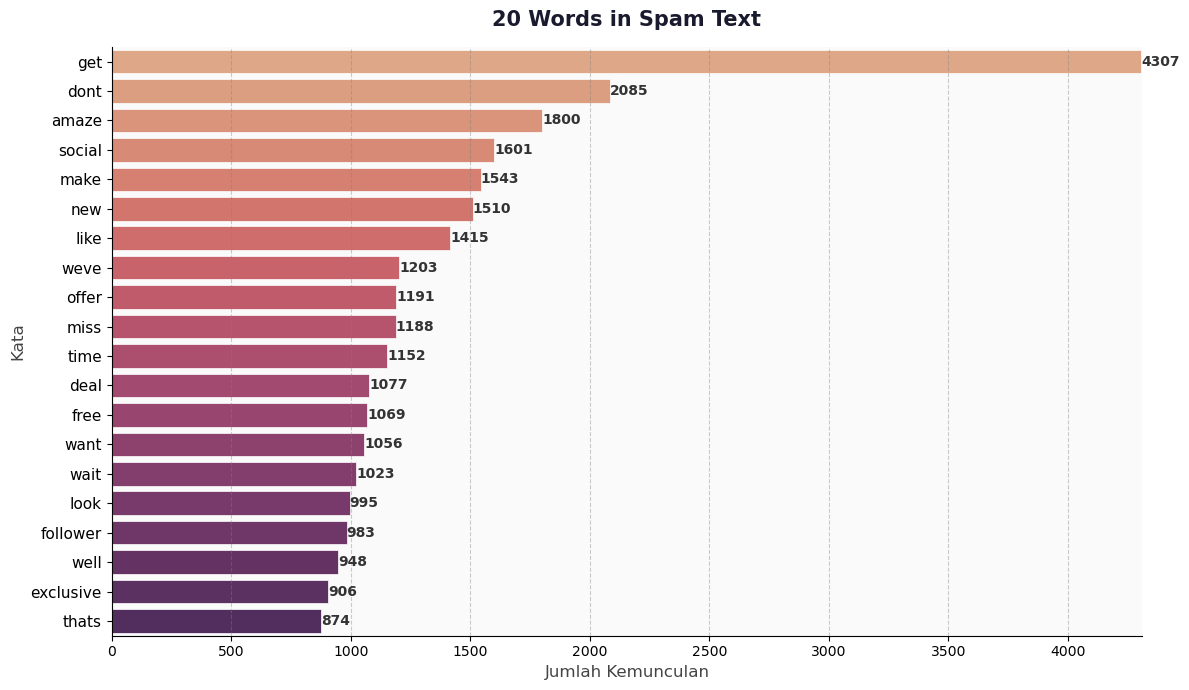

In [28]:
all_words = ' '.join(df[df['label'] == "spam"]['text_remove_sw']).split()
plot_20_word(all_words, title = "20 Words in Spam Text")



- Mayoritas kata yang ada di dalam email spam adalah kata “get”.
- Sebagian besar pola email spam memiliki intensi untuk menawarkan sesuatu. 

### Distribusi kata untuk label = not_spam

D:\Users\bsi80273\AppData\Local\Temp\ipykernel_12000\1313602366.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


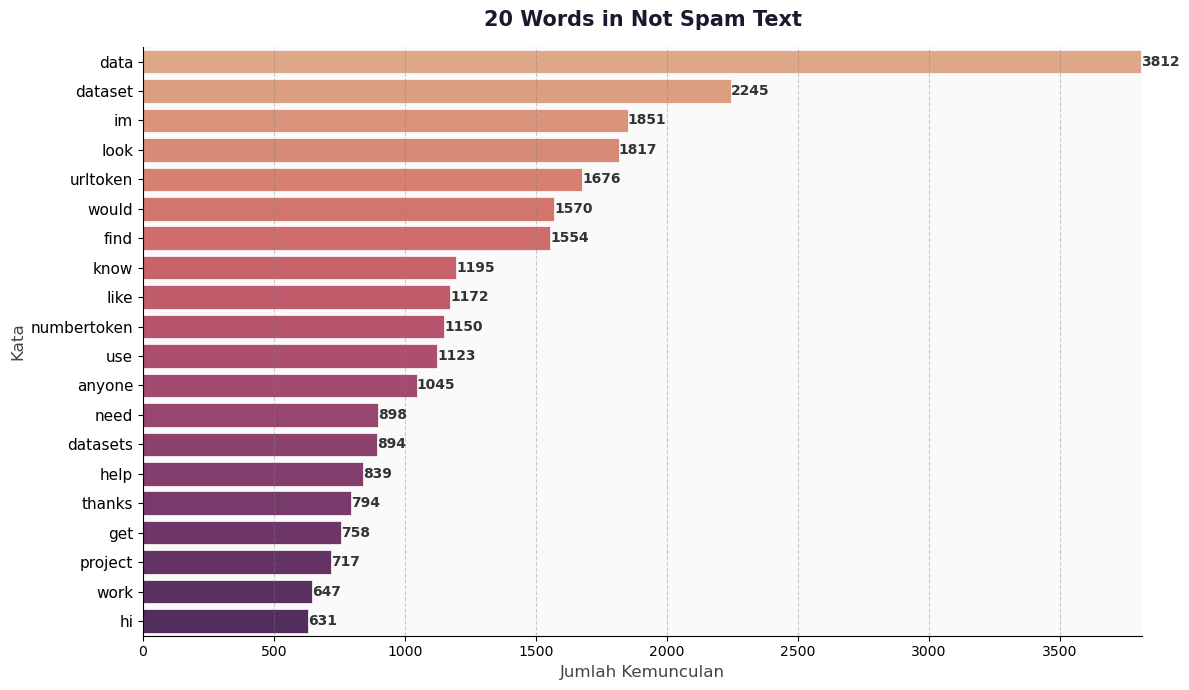

In [29]:
all_words = ' '.join(df[df['label'] == "not_spam"]['text_remove_sw']).split()
plot_20_word(all_words, title="20 Words in Not Spam Text")


- Mayoritas kata yang ada di dalam email spam adalah kata “data”.
- Sebagian besar pola email non spam memiliki intensi untuk membahas atau menayakan sesuatu. 

# Label Encoding

In [30]:
df['label'] = df['label'].map({"spam" : 1, "not_spam" : 0})
df.head()

,text,label,text_length,mask_text,text_normalized,lemma,text_remove_sw
0,hey I am looking for Xray baggage datasets can...,0,76,hey I am looking for Xray baggage datasets can...,hey i am looking for xray baggage datasets can...,hey i be look for xray baggage datasets can yo...,hey look xray baggage datasets provide
1,"""Get rich quick! Make millions in just days wi...",1,129,"""Get rich quick! Make millions in just days wi...",get rich quick make millions in just days with...,get rich quick make million in just day with o...,get rich quick make million day new revolution...
2,URGENT MESSAGE: YOU WON'T BELIEVE WHAT WE HAVE...,1,495,URGENT MESSAGE: YOU WON'T BELIEVE WHAT WE HAVE...,urgent message you wont believe what we have t...,urgent message you wont believe what we have t...,urgent message wont believe offer hey yeah eye...
3,[Google AI Blog: Contributing Data to Deepfake...,0,1057,[Google AI Blog: Contributing Data to Deepfake...,google ai blog contributing data to deepfake d...,google ai blog contribute data to deepfake det...,google ai blog contribute data deepfake detect...
4,Trying to see if anyone already has timestamps...,0,223,Trying to see if anyone already has timestamps...,trying to see if anyone already has timestamps...,try to see if anyone already have timestamps o...,try see anyone already timestamps key event ha...


# Split Data

Split train (80%) dan test (20%) data, menggunakan stratify sampling agar distribusi label pada train dan test seimbang

In [31]:
X = df["text_remove_sw"]
y = df["label"]
 
# Split train (80%) dan test (20%) data, menggunakan stratify sampling agar distribusi label pada train dan test seimbang
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state = 42, stratify = y
)

In [35]:
X_train.shape, X_test.shape

((6539,), (1635,))

# Features Encoding

- Vectorizer untuk semua fitur dengan tf-idf
- Menggunakan unigram dan bigram untuk lebih banyak menemukan pola. (kata "click this" lebih ada maknanya dibanding "click" )

In [32]:
# Vectorizer untuk semua fitur dengan tf-idf
tfidf = TfidfVectorizer(
    ngram_range = (1, 2), 
    sublinear_tf = True,
)
 
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)
 
print(f"\nShape matrix TF-IDF train : {X_train_tfidf.shape}")
print(f"Shape matrix TF-IDF test  : {X_test_tfidf.shape}")



Shape matrix TF-IDF train : (6539, 129391)
Shape matrix TF-IDF test  : (1635, 129391)


### Top Features

D:\Users\bsi80273\AppData\Local\Temp\ipykernel_12000\4022128957.py:56: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmap_name)  # pakai parameter


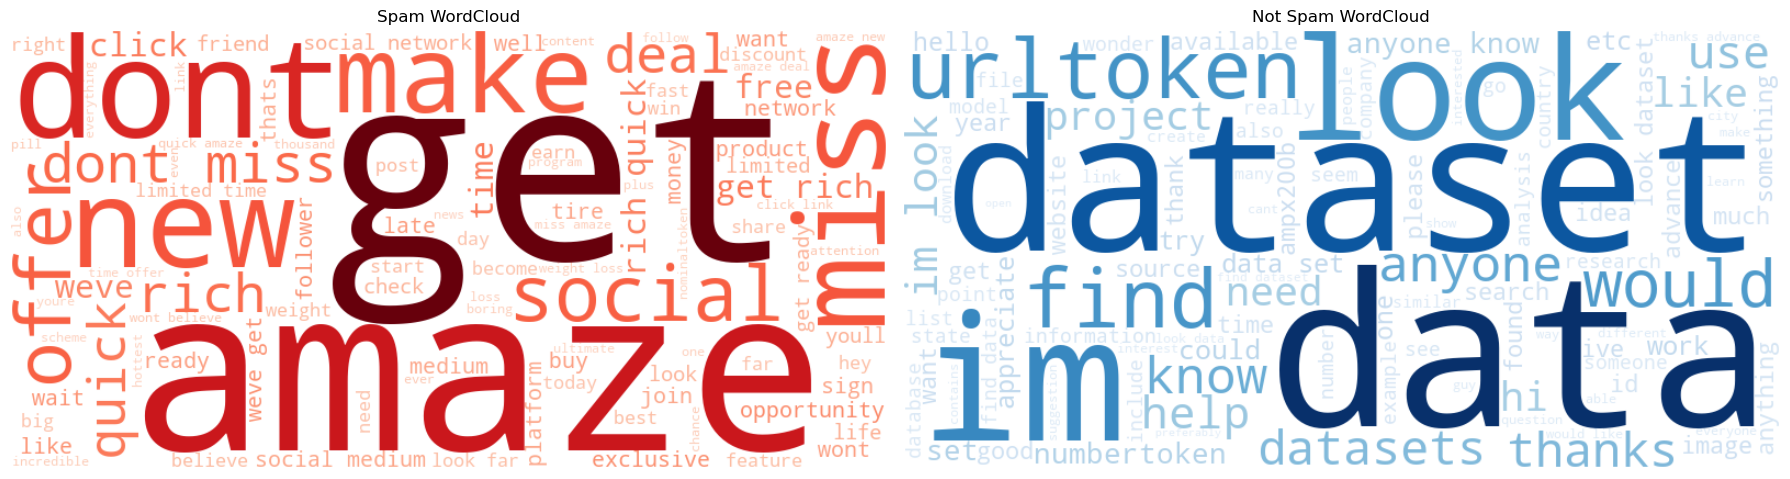

In [33]:

feature_names = tfidf.get_feature_names_out()

# spam
spam_mask = (y_train == 1).to_numpy()
X_spam = X_train_tfidf[spam_mask]
spam_scores = X_spam.mean(axis=0).A1

# not spam
ham_mask = (y_train == 0).to_numpy()
X_ham = X_train_tfidf[ham_mask]
ham_scores = X_ham.mean(axis=0).A1

# =========================
# DataFrame
# =========================

spam_df = pd.DataFrame({
    'feature': feature_names,
    'score': spam_scores
}).sort_values(by='score', ascending=False)

ham_df = pd.DataFrame({
    'feature': feature_names,
    'score': ham_scores
}).sort_values(by='score', ascending=False)

# =========================
# Ambil top feature
# =========================

top_n = 100

spam_words = dict(
    zip(
        spam_df['feature'].head(top_n),
        spam_df['score'].head(top_n)
    )
)

ham_words = dict(
    zip(
        ham_df['feature'].head(top_n),
        ham_df['score'].head(top_n)
    )
)

# =========================
# Color Function
# makin terang = score makin tinggi
# =========================

def make_color_func(freq_dict, cmap_name='autumn'):  # tambah parameter cmap_name

    max_score = max(freq_dict.values())
    norm = mcolors.Normalize(vmin=0, vmax=max_score)
    cmap = cm.get_cmap(cmap_name)  # pakai parameter

    def color_func(word, *args, **kwargs):
        score = freq_dict[word]
        rgba = cmap(norm(score))
        r, g, b, _ = rgba
        return f"rgb({int(r*255)}, {int(g*255)}, {int(b*255)})"

    return color_func


# =========================
# Wordcloud
# =========================

wc_spam = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate_from_frequencies(spam_words)

wc_spam.recolor(
    color_func=make_color_func(spam_words, cmap_name='Reds')
)

wc_ham = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate_from_frequencies(ham_words)

wc_ham.recolor(
    color_func=make_color_func(ham_words, cmap_name='Blues')
)

# =========================
# Plot Side by Side
# =========================

fig, ax = plt.subplots(1, 2, figsize=(18,8))

ax[0].imshow(wc_spam, interpolation='bilinear')
ax[0].set_title('Spam WordCloud')
ax[0].axis('off')

ax[1].imshow(wc_ham, interpolation='bilinear')
ax[1].set_title('Not Spam WordCloud')
ax[1].axis('off')

plt.tight_layout()
plt.show()

- Sebagian besar pola email spam memiliki intensi untuk menawarkan sesuatu. 
- Sebagian besar pola email non spam memiliki intensi untuk membahas atau menayakan sesuatu (spesifiknya data). 

In [34]:
spam_df

,feature,score
47851,get,0.036030
5817,amaze,0.027107
33113,dont,0.025113
76596,new,0.020069
72981,miss,0.019918
...,...,...
59827,investigate question,0.000000
59826,investigate property,0.000000
59825,investigate issue,0.000000
59824,investigate impact,0.000000


In [35]:
ham_df

,feature,score
26506,data,0.030001
27890,dataset,0.025431
55840,im,0.019863
67284,look,0.018630
119498,urltoken,0.018615
...,...,...
69270,make dollar,0.000000
69271,make dream,0.000000
69273,make drool,0.000000
69274,make drop,0.000000


### Spam vs Non spam Vector

In [36]:
import numpy as np
import pandas as pd
import plotly.express as px

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.manifold import TSNE

# ======================
# TF-IDF
# ======================

tfidf = TfidfVectorizer(
    max_features=500,
    ngram_range=(1,2),
    min_df=2,
    sublinear_tf=True
)

X_tfidf = tfidf.fit_transform(df['text_remove_sw'])

words = np.array(tfidf.get_feature_names_out())

# ======================
# WORD LABELING
# ======================

spam_mean = np.asarray(
    X_tfidf[(df['label']==1).values].mean(axis=0)
).flatten()

ham_mean = np.asarray(
    X_tfidf[(df['label']==0).values].mean(axis=0)
).flatten()

word_class = np.where(
    spam_mean > ham_mean,
    'Spam Word',
    'Non Spam Word'
)

# ======================
# WORD VECTORS
# ======================

word_vectors = X_tfidf.T.toarray()

# ======================
# t-SNE 3D
# ======================

tsne = TSNE(
    n_components=3,
    perplexity=30,
    random_state=42,
    init='pca'
)

X_3d = tsne.fit_transform(word_vectors)

# ======================
# DATAFRAME
# ======================

plot_df = pd.DataFrame({
    'x': X_3d[:,0],
    'y': X_3d[:,1],
    'z': X_3d[:,2],
    'word': words,
    'class': word_class,
    'spam_score': spam_mean,
    'ham_score': ham_mean
})


plot_df

,x,y,z,word,class,spam_score,ham_score
0,74.680908,15.991132,63.871422,10,Spam Word,0.010035,0.004082
1,31.395924,5.039009,-15.139310,100,Spam Word,0.004180,0.003716
2,-38.406750,-19.782589,85.002930,50,Spam Word,0.009030,0.002192
3,38.324142,87.928421,10.586048,able,Non Spam Word,0.002609,0.011353
4,-39.034595,-43.191185,-25.547791,access,Spam Word,0.014141,0.007491
...,...,...,...,...,...,...,...
495,-31.347963,17.788404,44.139183,yo,Spam Word,0.007191,0.000105
496,-83.390381,-34.864269,-32.726593,youll,Spam Word,0.025035,0.000289
497,-371.517303,-232.865280,15.049846,youll get,Spam Word,0.006169,0.000000
498,-29.927883,-29.774759,28.510002,youre,Spam Word,0.016024,0.000690


In [37]:


# ======================
# PLOTLY
# ======================

fig = px.scatter_3d(
    plot_df,
    x='x',
    y='y',
    z='z',
    color='class',
    text='word',
    hover_data={
        'spam_score': True,
        'ham_score': True
    },
    color_discrete_map={
        'Spam Word': 'red',
        'Non Spam Word': 'blue'
    },
    title='3D Spam vs Non Spam Word Visualization'
)

fig.update_traces(
    marker=dict(size=4)
)

fig.show()

- Kata yang spam dan non spam membentuk suatu cluster

# Phase 1

- Pada parameter default, semua model (Logistic Regression ataupun SVC) memiliki performa yang sangat tinggi. Untuk weighted precision ada di angka 99%.
- Berdasarkan nilai standar deviasi cross validation. Model baseline SVC lebih stabil dibandingkan logistic regression.
- Angka 99% ini menucrigakan dan kemungkinan besar overfitting. Kemungkinan besar disebabkan oleh tfidf yang menghasilkan fitur yang terlalu banyak. Sehingga perlu dilakukan feature selection.

## Logistic Reg

### Baseline

In [55]:
# Cross Validation
cv = StratifiedKFold(n_splits = 5, shuffle = True, random_state = 42)
lr_phase_1 = LogisticRegression(max_iter = 1000)

lr_phase_1_scores = cross_val_score(lr_phase_1, X_train_tfidf, y_train, cv = cv, scoring = 'precision_weighted')

print("Akurasi tiap fold :", lr_phase_1_scores)
print(f"Rata-rata          : {lr_phase_1_scores.mean():.4f}")
print(f"Std deviasi        : {lr_phase_1_scores.std():.4f}")

lr_phase_1.fit(X_train_tfidf, y_train)

# Evaluasi di test set
y_pred = lr_phase_1.predict(X_test_tfidf)
print(classification_report(y_test, y_pred))


Akurasi tiap fold : [0.99099249 0.99620664 0.99618797 0.99467761 0.99320847]
Rata-rata          : 0.9943
Std deviasi        : 0.0020
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       810
           1       1.00      1.00      1.00       825

    accuracy                           1.00      1635
   macro avg       1.00      1.00      1.00      1635
weighted avg       1.00      1.00      1.00      1635



## SVC

In [56]:
svc_phase_1 = SVC()

cv = StratifiedKFold(n_splits = 5, shuffle = True, random_state = 42)
svc_phase_1_scores = cross_val_score(svc_phase_1, X_train_tfidf, y_train, cv = cv, scoring = 'precision_weighted')

print("Akurasi tiap fold :", svc_phase_1_scores)
print(f"Rata-rata          : {svc_phase_1_scores.mean():.4f}")
print(f"Std deviasi        : {svc_phase_1_scores.std():.4f}")

svc_phase_1.fit(X_train_tfidf, y_train)
y_pred_svc = svc_phase_1.predict(X_test_tfidf)

print("\n=== Evaluasi di Test Set ===")
print(classification_report(y_test, y_pred_svc))

Akurasi tiap fold : [0.99247093 0.99620664 0.99694663 0.99694663 0.99695836]
Rata-rata          : 0.9959
Std deviasi        : 0.0017

=== Evaluasi di Test Set ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       810
           1       1.00      1.00      1.00       825

    accuracy                           1.00      1635
   macro avg       1.00      1.00      1.00      1635
weighted avg       1.00      1.00      1.00      1635



# Statistic Inferensial

- H₀: Model yang dilatih menggunakan seluruh fitur TF-IDF (tanpa seleksi fitur) memiliki performa yang sama atau lebih tinggi dibandingkan model yang dilatih menggunakan 20% fitur TF-IDF teratas berdasarkan skor chi-square.
- H₁: Model yang dilatih menggunakan 20% fitur TF-IDF teratas (berdasarkan seleksi fitur chi-square) memiliki performa lebih tinggi dibandingkan model yang dilatih menggunakan seluruh fitur TF-IDF tanpa seleksi.
------
- H₀ → Performa model pada TfidfVectorizer penuh, tanpa SelectPercentile
- H₁ → Performa model pada TfidfVectorizer + SelectPercentile(chi2, percentile=20)
------
Tolak H₀: H₁ > H₀   
Gagal Tolak H₀: H₁ <= H₀

# Phase 2

- Metode feature selection yang digunakan adalah menyeleksi hanya 20% dari kata yang paling penting dari tf-idf. angka 20% didapatkan dari prinsip pareto.
- Setelah dilakukan feature selection, pada parameter default, untuk semua model (Logistic Regression ataupun SVC) memiliki performa yang sama tingginya seperti sebelum feture selection. Untuk weighted precision ada di angka 99%.
- Setelah dilakikan feature selection, rata rata weighted dan standar deviasi kedua model meningkat:
    - rata rata weighted precision:
        - Logistic Regression: 0.9943 -> 0.9943
        - SVC: 0.9959 -> 0.9974
    - Standar deviasi:
        - Logistic Regression: 0.0020 -> 0.0017
        - SVC: 0.0017 -> 0.0011
- Sehingga hasil dari menggunakan feature selection terbukti berhasil tolak H₀ untuk statistik inferensial

## Cek korelasi

In [42]:
# Melakukan seleksi 20% dari fitur yang paling penting dari tf-idf
selector = SelectPercentile(chi2, percentile = 20)
X_train_selected = selector.fit_transform(X_train_tfidf, y_train)
X_test_selected  = selector.transform(X_test_tfidf)


## Logistic Regression

### Baseline

In [57]:
# Cross Validation
cv = StratifiedKFold(n_splits = 5, shuffle = True, random_state = 42)
lr_phase_2 = LogisticRegression(max_iter = 1000)

lr_phase_2_scores = cross_val_score(lr_phase_2, X_train_selected, y_train, cv = cv, scoring = 'precision_weighted')

print("Akurasi tiap fold :", lr_phase_2_scores)
print(f"Rata-rata          : {lr_phase_2_scores.mean():.4f}")
print(f"Std deviasi        : {lr_phase_2_scores.std():.4f}")

lr_phase_2.fit(X_train_selected, y_train)

# Evaluasi di test set
y_pred = lr_phase_2.predict(X_test_selected)
print(classification_report(y_test, y_pred))


Akurasi tiap fold : [0.99173059 0.99620664 0.99618797 0.99392588 0.99320847]
Rata-rata          : 0.9943
Std deviasi        : 0.0017
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       810
           1       1.00      1.00      1.00       825

    accuracy                           1.00      1635
   macro avg       1.00      1.00      1.00      1635
weighted avg       1.00      1.00      1.00      1635



## SVC

### Baseline

In [58]:
svc_phase_2 = SVC()

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
svc_phase_2_scores = cross_val_score(svc_phase_2, X_train_selected, y_train, cv=cv, scoring='precision_weighted')

print("Akurasi tiap fold :", svc_phase_2_scores)
print(f"Rata-rata          : {svc_phase_2_scores.mean():.4f}")
print(f"Std deviasi        : {svc_phase_2_scores.std():.4f}")

svc_phase_2.fit(X_train_selected, y_train)
y_pred_svc = svc_phase_2.predict(X_test_selected)

print("\n=== Evaluasi di Test Set ===")
print(classification_report(y_test, y_pred_svc))

Akurasi tiap fold : [0.99620664 0.99696066 0.99847565 0.99770762 0.99771526]
Rata-rata          : 0.9974
Std deviasi        : 0.0008

=== Evaluasi di Test Set ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       810
           1       1.00      1.00      1.00       825

    accuracy                           1.00      1635
   macro avg       1.00      1.00      1.00      1635
weighted avg       1.00      1.00      1.00      1635



# Hyperparameter Tuning

- Karena performa model mengingkat setelah feture selection, maka langkah selanjutnya akan menggunakan data yang sudah di feature selection
- Setelah dilakukan hyperparameter tuning dan menggunakan feature selection:
    - rata rata weighted precision:
        - Logistic Regression: 0.9943 -> 0.9943
        - SVC: 0.9974 -> 0.9988
    - Standar deviasi:
        - Logistic Regression: 0.0017 -> 0.0011
        - SVC: 0.0008 -> 0.0006
- Best params untuk Logistic Regression: {'C': 1, 'penalty': 'l2', 'solver': 'liblinear'}
- Best params untuk SVC:  {'C': 100, 'gamma': 0.1, 'kernel': 'rbf'}

In [45]:
def hyperparameter_tuning(param_grid, estimator, cv, X, y):
    # GridSearchCV
    grid_search = GridSearchCV(
        estimator = estimator,
        param_grid = param_grid,
        cv = cv,
        scoring='precision_weighted',
        n_jobs = -1,
        verbose = 1,
        refit = True           
    )

    grid_search.fit(X, y)

    # Hasil best params
    print("Best Parameters :", grid_search.best_params_)
    print(f"Best CV Score   : {grid_search.best_score_:.4f}")

    best_lr = grid_search.best_estimator_
    scores = cross_val_score(best_lr, X, y, cv=cv, scoring='precision_weighted')
    return grid_search, scores
    

In [49]:
param_grid = {
    'C': [0.01, 0.1, 1],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear', 'lbfgs', 'saga']
}
estimator = LogisticRegression(max_iter = 1000)
grid_lr, grid_lr_scores = hyperparameter_tuning(param_grid, estimator, cv, X_train_selected, y_train)

print("\nAkurasi tiap fold :", grid_lr_scores)
print(f"Rata-rata          : {grid_lr_scores.mean():.4f}")
print(f"Std deviasi        : {grid_lr_scores.std():.4f}")

# Evaluasi di test set
y_pred = grid_lr.predict(X_test_selected)
print("\n", classification_report(y_test, y_pred))


Fitting 5 folds for each of 18 candidates, totalling 90 fits


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py:516: FitFailedWarning:


15 fits failed out of a total of 90.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
15 fits failed with the following error:
Traceback (most recent call last):
  File "c:\ProgramData\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\ProgramData\anaconda3\Lib\site-packages\sklearn\base.py", line 1365, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "c:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py", line 1218, in fit
    solver = 

Best Parameters : {'C': 1, 'penalty': 'l2', 'solver': 'liblinear'}
Best CV Score   : 0.9943

Akurasi tiap fold : [0.99173059 0.99620664 0.99618797 0.99392588 0.99320847]
Rata-rata          : 0.9943
Std deviasi        : 0.0017

               precision    recall  f1-score   support

           0       1.00      1.00      1.00       810
           1       1.00      1.00      1.00       825

    accuracy                           1.00      1635
   macro avg       1.00      1.00      1.00      1635
weighted avg       1.00      1.00      1.00      1635



In [50]:
param_grid = {
    'kernel': ['linear', 'rbf', 'poly'],
    'gamma': ['scale', 'auto', 0.001, 0.01, 0.1],
    'C': [0.01, 0.1, 1, 10, 100],
} 
estimator = SVC()
grid_svc, grid_svc_scores = hyperparameter_tuning(param_grid, estimator, cv, X_train_selected, y_train)

print("\nAkurasi tiap fold :", grid_svc_scores)
print(f"Rata-rata          : {grid_svc_scores.mean():.4f}")
print(f"Std deviasi        : {grid_svc_scores.std():.4f}")

# Evaluasi di test set
y_pred = grid_svc.predict(X_test_selected)
print("\n", classification_report(y_test, y_pred))


Fitting 5 folds for each of 75 candidates, totalling 375 fits
Best Parameters : {'C': 100, 'gamma': 0.1, 'kernel': 'rbf'}
Best CV Score   : 0.9988

Akurasi tiap fold : [0.99771699 0.99923665 0.99847095 0.99923663 0.99923607]
Rata-rata          : 0.9988
Std deviasi        : 0.0006

               precision    recall  f1-score   support

           0       1.00      1.00      1.00       810
           1       1.00      1.00      1.00       825

    accuracy                           1.00      1635
   macro avg       1.00      1.00      1.00      1635
weighted avg       1.00      1.00      1.00      1635



# Model Selection

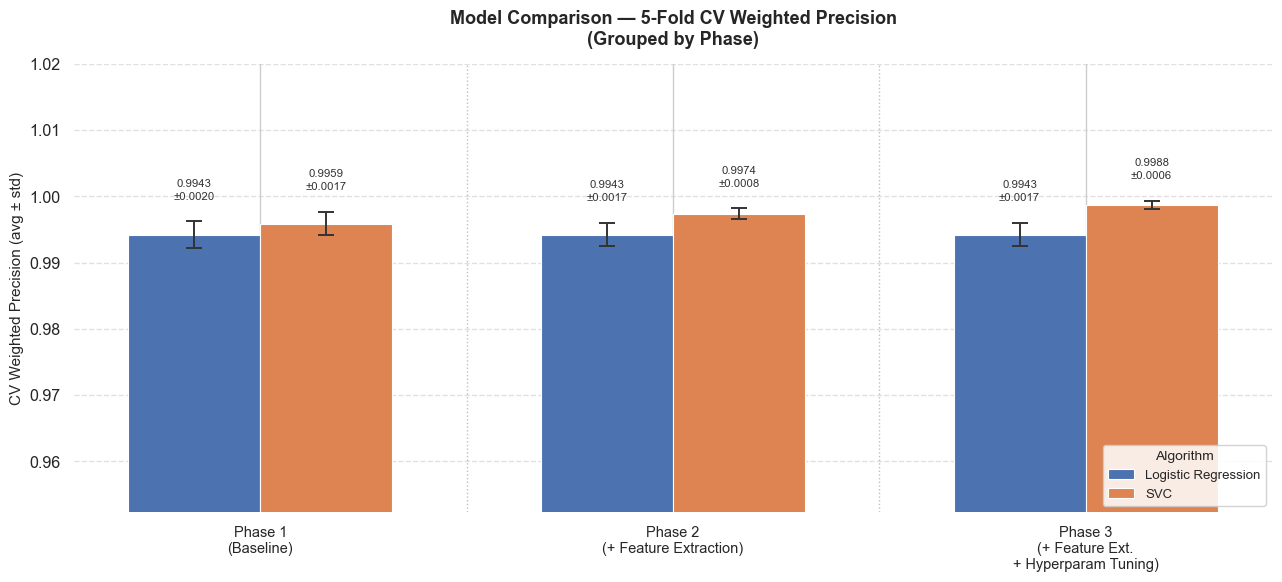

In [62]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# ── Data ─────────────────────────────────────────────────────────────────────
phases = [
    "Phase 1\n(Baseline)",
    "Phase 2\n(+ Feature Extraction)",
    "Phase 3\n(+ Feature Ext.\n+ Hyperparam Tuning)",
]

lr_scores  = [lr_phase_1_scores,    lr_phase_2_scores,    grid_lr_scores]
svc_scores = [svc_phase_1_scores,   svc_phase_2_scores,   grid_svc_scores]

lr_means  = [s.mean() for s in lr_scores]
lr_stds   = [s.std()  for s in lr_scores]
svc_means = [s.mean() for s in svc_scores]
svc_stds  = [s.std()  for s in svc_scores]

# ── Plot ──────────────────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", font_scale=1.05)
fig, ax = plt.subplots(figsize=(13, 6))

x     = np.arange(len(phases))
width = 0.32
palette = {"LR": "#4C72B0", "SVC": "#DD8452"}

err_kw = dict(elinewidth=1.4, ecolor="#333333", capthick=1.4, capsize=6)

bars_lr = ax.bar(
    x - width / 2, lr_means, width,
    yerr=lr_stds, color=palette["LR"],
    edgecolor="white", linewidth=0.8,
    error_kw=err_kw, zorder=3, label="Logistic Regression",
)
bars_svc = ax.bar(
    x + width / 2, svc_means, width,
    yerr=svc_stds, color=palette["SVC"],
    edgecolor="white", linewidth=0.8,
    error_kw=err_kw, zorder=3, label="SVC",
)

# ── Value labels ──────────────────────────────────────────────────────────────
def add_labels(bars, means, stds):
    for bar, mean, std in zip(bars, means, stds):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            mean + std + 0.003,
            f"{mean:.4f}\n±{std:.4f}",
            ha="center", va="bottom",
            fontsize=8.2, color="#333333", linespacing=1.4,
        )

add_labels(bars_lr,  lr_means,  lr_stds)
add_labels(bars_svc, svc_means, svc_stds)

# ── Aesthetics ────────────────────────────────────────────────────────────────
ax.set_xticks(x)
ax.set_xticklabels(phases, fontsize=10.5)
ax.set_ylabel("CV Weighted Precision (avg ± std)", fontsize=11)
ax.set_title(
    "Model Comparison — 5-Fold CV Weighted Precision\n(Grouped by Phase)",
    fontsize=13, fontweight="bold", pad=14,
)

all_means = lr_means + svc_means
all_stds  = lr_stds  + svc_stds
y_min = min(m - s for m, s in zip(all_means, all_stds))
ax.set_ylim(max(0, y_min - 0.04), min(1.02, max(all_means) + max(all_stds) + 0.07))

ax.yaxis.grid(True, linestyle="--", alpha=0.6, zorder=0)
ax.set_axisbelow(True)
ax.legend(title="Algorithm", title_fontsize=10, fontsize=9.5,
          loc="lower right", framealpha=0.85)

# phase separator lines
ax.axvline(0.5, color="gray", linestyle=":", linewidth=1, alpha=0.5)
ax.axvline(1.5, color="gray", linestyle=":", linewidth=1, alpha=0.5)

sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

# Build Data Pipeline

- Model yang dipilih untuk di deploy adalah logistic regression yang dilatih setelah feature selection
- Model ini dipilih karena lebih baik daripada yang dilatih tanpa feature selection.
- Model ini dipilih juga lebih ringan dibandingkan SVC. 
- Model dan preprocess akan di load dalam file .pkl

In [51]:
pipeline = Pipeline([
    *preprocess_pipeline(elongation_smart = True).steps,
    ('tfidf', tfidf),
    ('selector', selector),
    ('model', lr_phase_2)
])

pipeline.fit(X_train, y_train)

with open('pipeline.pkl', 'wb') as f:
    pickle.dump(pipeline, f)


15:41:25 | INFO | URLMasker              |   6539 rows | 0.057s
15:41:25 | INFO | CurrencyMasker         |   6539 rows | 0.050s
15:41:26 | INFO | ElongationNormalizer   |   6539 rows | 0.819s
15:41:26 | INFO | PunctuationRemover     |   6539 rows | 0.099s
15:41:26 | INFO | Casefolding            |   6539 rows | 0.004s
15:41:39 | INFO | POSLemmatizer          |   6539 rows | 12.307s
15:41:39 | INFO | StopwordRemover        |   6539 rows | 0.405s


# Testing dengan Test dataset

- Model tidak overfitting pada test dataset.

In [52]:
test_set = pd.read_parquet('test.parquet')
test_set.head()

,text,label
0,"Deezer.com 10,406,168 Artist DB\n\nWe have sc...",not_spam
1,🚨 ATTENTION ALL USERS! 🚨\n\n🆘 Are you looking ...,spam
2,I'm working on a stats project to test some of...,not_spam
3,"[[Sorry, I cannot generate inappropriate or sp...",spam
4,L@@k at these Unbelievable diet pills that can...,spam


In [53]:
test_set['label'] = test_set['label'].map({'not_spam': 0, 'spam': 1})

In [54]:
with open('pipeline.pkl', 'rb') as f:
    pipeline_default = pickle.load(f)


y_pred_default = pipeline_default.predict(test_set['text'])
print(classification_report(test_set['label'], y_pred_default))

15:42:02 | INFO | URLMasker              |   2725 rows | 0.039s
15:42:02 | INFO | CurrencyMasker         |   2725 rows | 0.081s
15:42:03 | INFO | ElongationNormalizer   |   2725 rows | 0.820s
15:42:03 | INFO | PunctuationRemover     |   2725 rows | 0.078s
15:42:03 | INFO | Casefolding            |   2725 rows | 0.002s
15:42:09 | INFO | POSLemmatizer          |   2725 rows | 6.427s
15:42:09 | INFO | StopwordRemover        |   2725 rows | 0.257s


              precision    recall  f1-score   support

           0       0.98      0.99      0.99      1350
           1       0.99      0.98      0.99      1375

    accuracy                           0.99      2725
   macro avg       0.99      0.99      0.99      2725
weighted avg       0.99      0.99      0.99      2725



# Kesimpulan

- Email spam dapat diidentifikasi dari karakter yang digunakan, seperti emoji, url dengan domain yang tidak resmi (.io, net)
- Panjang karakter yang ada di email juga berpotensi untuk menjadi email spam (> 500 karakter, berpotensi menjadi spam).
- Email spam biasanya mengandung ajakan atau penawaran tentang sesuatu ke recipent
- Email non spam biasanya menanyakan sesuatu ke recipent

# Rekomendasi

Agar email anda tidak terklasifikasi sebagai spam:
- pastikan tidak mengandung url/link dengan domain yang tidak terpercaya
- pastikan panjang karakter kurang dari 500 
- Tidak mengandung banyak emoji